#### Compute pathway acts for the subnetwork created by looking for hubs (TDA mega cluster) and their targets

In [1]:
import tf_pathway_link as fc
import pandas as pd
import seaborn as sns
import decoupler as dc
import numpy as np
import matplotlib.pyplot as plt
import ast
from collections import defaultdict
plt.rcParams['svg.fonttype'] = 'none'
import plotly.graph_objects as go
from matplotlib.colors import to_rgb
from upsetplot import UpSet, from_indicators

/home/mmultari/miniconda3/envs/GRN/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
mercator_res = pd.read_csv("../Data/Mercator_annotation_Sly_4_1.txt", sep="\t", quotechar="'")
mercator_res["IDENTIFIER"]= mercator_res["IDENTIFIER"].str.split(".").str.get(0)
grn_global = pd.read_csv("Data/Curated_gene_regulatory_network.tsv", sep="\t")
grn_global.rename(columns={"TF": "source", "Target_Gene": "target"}, inplace=True)

In [3]:
annotation = fc.process_annotation(mercator_res, grn_global)
stats_dea = fc.import_and_process_dea('../DEA/Merge_stat_all.tsv', grn_global)
tf_acts = fc.import_and_process_acts('Results_hubs_activity_stats_mega_cluster-SUPP_table.tsv', grn_global)
network_pathway_mercator = annotation.copy()
network_pathway_mercator.rename(columns={'IDENTIFIER': 'target', 'ANNOT': 'source'}, inplace=True)
network_pathway_mercator = network_pathway_mercator.drop_duplicates()

In [4]:
conditions = ['Pinfestans','Cfulvum','PSTVd_S23','PSTVd_M','Bcinerea','Mincognita_7dpi','Mincognita_14dpi']

In [5]:
pathway_acts, pathway_pvals = dc.run_mlm(mat=stats_dea.T, net=network_pathway_mercator, verbose=True, weight=None)

Running mlm on mat with 7 samples and 1786 targets for 30 sources.


In [6]:
shuffle_res_pathway = pd.read_csv("../Shuffle/results/tf_summary_all_conditions_pathways.csv")
shuffle_res_pathway = shuffle_res_pathway.pivot(index='TF', columns='condition', values='significant')
shuffle_res_pathway.columns = shuffle_res_pathway.columns.str.replace('stat_', '')
shuffle_res_pathway = shuffle_res_pathway[sorted(shuffle_res_pathway.columns)]

In [7]:
pvals = pathway_pvals.T
pvals = pvals[sorted(pvals.columns)]
signif_pval = pvals <= 0.05
shuffle_res_compare = shuffle_res_pathway & signif_pval
mask_significant = shuffle_res_compare.any(axis=1)

<Axes: >

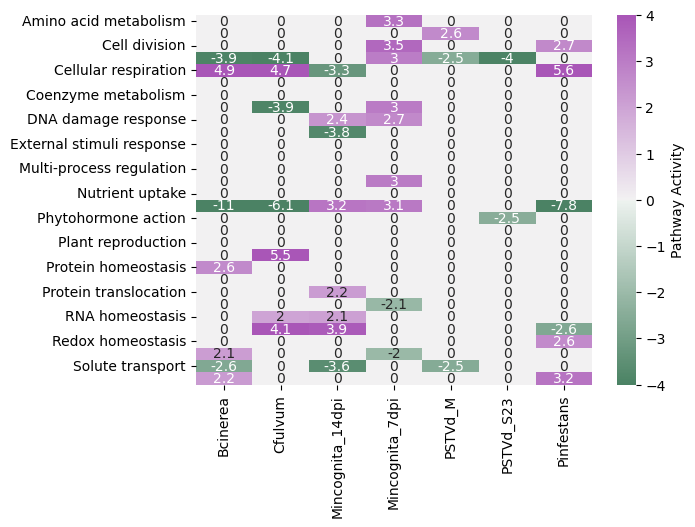

In [8]:
acts = pathway_acts.T
acts = acts[sorted(acts.columns)]

significant_acts = acts.where(shuffle_res_compare, 0)
sns.heatmap(significant_acts, 
               cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True), 
               center=0, 
               cbar_kws={'label': 'Pathway Activity'}, 
               vmin = -4, 
               vmax = 4, annot=True) 

In [9]:
pathway_acts_value = acts.loc[mask_significant]

In [10]:
pathway_acts_value

,Bcinerea,Cfulvum,Mincognita_14dpi,Mincognita_7dpi,PSTVd_M,PSTVd_S23,Pinfestans
Amino acid metabolism,-0.926203,-0.364299,0.293423,3.304141,0.211699,0.504668,1.244096
Carbohydrate metabolism,-1.523799,-0.864984,-0.937543,1.272934,2.649128,0.886840,0.627571
Cell division,-0.797180,-0.436389,0.488623,3.518468,-1.165057,-2.112219,2.681425
Cell wall organisation,-3.924538,-4.130590,-0.822918,2.998530,-2.523283,-3.961480,1.453832
Cellular respiration,4.893750,4.698483,-3.273935,-1.060004,1.265588,1.116087,5.602279
Cytoskeleton organisation,-1.356690,-3.876691,-2.315607,3.010026,-0.864517,-1.857218,1.448388
DNA damage response,0.050745,1.524235,2.406235,2.672896,0.171837,1.235492,-0.546842
Enzyme classification,-0.154444,0.512140,-3.780391,-0.620154,-0.025938,-0.855865,2.411097
Nucleotide metabolism,1.927109,1.472814,0.570210,3.018277,-0.470376,0.538568,0.963637
Photosynthesis,-11.039056,-6.148908,3.183028,3.080750,-1.551609,-0.347693,-7.810866


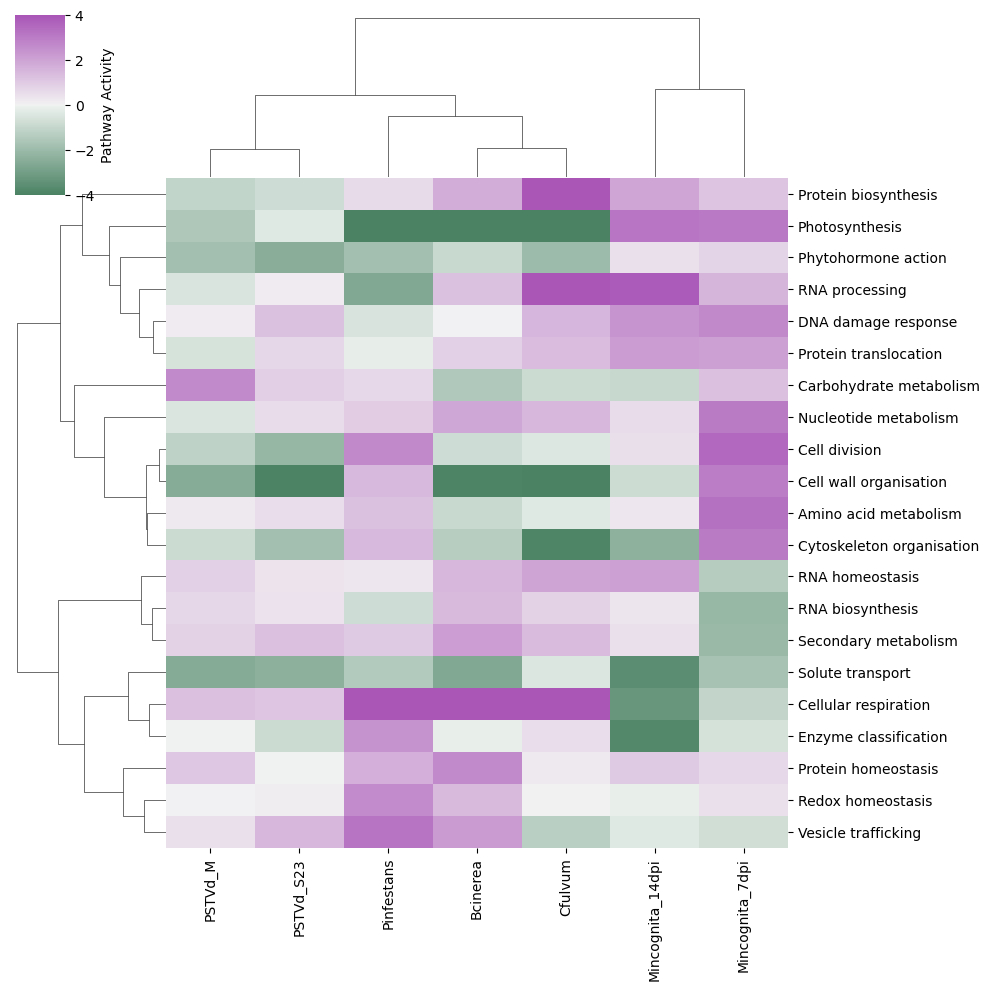

In [11]:

sns.clustermap(pathway_acts_value, 
               cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True), 
               center=0, 
               cbar_kws={'label': 'Pathway Activity'}, 
               vmin = -4, 
               vmax = 4,
               method='average',
               metric='correlation')
plt.savefig(f'Plot/Clustermap_signif_pathway_corrected.svg', format='svg')

In [12]:
# pvals = pathway_pvals.T
# acts = pathway_acts.T

# significant_pvals = pvals[pvals[conditions].apply(lambda x: x <= 0.05, axis=1).any(axis=1)]
# significant_acts = acts[acts.index.isin(significant_pvals.index)]
# significant_acts.iloc[:, 0:] = np.where(significant_pvals.iloc[:, 0:] <= 0.05, significant_acts.iloc[:, 0:], 0)
# significant_acts = significant_acts[sorted(significant_acts.columns)]
# sns.heatmap(significant_acts, 
#                cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True), 
#                center=0, 
#                cbar_kws={'label': 'Pathway Activity'}, 
#                vmin = -4, 
#                vmax = 4, annot=True) 

In [13]:
pathway_acts_signif = significant_acts.copy()

In [14]:
triplet = fc.compute_tf_pathway_association(tf_activity=tf_acts, pathway_activity=pathway_acts_signif, tf_target_net=grn_global, pathway_target_net=network_pathway_mercator, method='sign')

Sankey pathway TDA

In [15]:
TDA_res = pd.read_csv('Results_hubs_activity_stats_mega_cluster-SUPP_table.tsv', sep='\t')
TDA_res["MegaCluster"] = TDA_res["MegaCluster"].apply(ast.literal_eval)

In [16]:
group_dict = defaultdict(list)

for gene, pos_list in zip(TDA_res["OLN"], TDA_res["MegaCluster"]):
    for pos in pos_list:
        group_dict[pos].append(gene)

In [17]:
def sankey_pathway_activity(df: pd.DataFrame, title="Pathway activity Sankey", vmax=4.0):
    """
    Create a Sankey diagram of pathway activity with sorted flows and fixed layout.

    Features
    --------
    - Left (conditions) ordered top→bottom by total outgoing flow count.
    - Right (pathways) ordered top→bottom by total incoming flow count.
    - Edges sorted per node by activity for a smooth gradient top→bottom.
    - All edges have constant width; color represents signed activity.
    - Node placement fixed explicitly (x,y).
    """

    # --- compute flow counts ---
    pathway_counts = (df != 0).sum(axis=1)
    condition_counts = (df != 0).sum(axis=0)
    pathway_counts = pathway_counts[pathway_counts > 0]
    condition_counts = condition_counts[condition_counts > 0]

    # --- sort nodes by flow counts ---
    sorted_conditions = condition_counts.sort_values(ascending=False).index.tolist()
    sorted_pathways = pathway_counts.sort_values(ascending=False).index.tolist()

    # --- node labels ---
    cond_labels = [f"{c} ({condition_counts[c]})" for c in sorted_conditions]
    path_labels = [f"{pw} ({pathway_counts[pw]})" for pw in sorted_pathways]
    all_nodes = cond_labels + path_labels

    node_idx = {name: i for i, name in enumerate(all_nodes)}

    # --- build all links ---
    cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)
    links = []

    for cond in sorted_conditions:
        for pw in sorted_pathways:
            v = df.loc[pw, cond]
            if v != 0:
                t = (v / vmax + 1) / 2
                rgba = cmap(t)
                color = f"rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, {rgba[3]:.2f})"
                links.append({
                    "source": node_idx[f"{cond} ({condition_counts[cond]})"],
                    "target": node_idx[f"{pw} ({pathway_counts[pw]})"],
                    "value": 1,       # constant width
                    "raw": v,         # for sorting
                    "color": color
                })

    links_df = pd.DataFrame(links)

    # --- sort outgoing per condition ---
    sorted_links = []
    for cond_idx in [node_idx[f"{c} ({condition_counts[c]})"] for c in sorted_conditions]:
        cond_links = links_df[links_df.source == cond_idx].sort_values(by="raw")
        sorted_links.append(cond_links)

    # --- sort incoming per pathway ---
    for pw_idx in [node_idx[f"{pw} ({pathway_counts[pw]})"] for pw in sorted_pathways]:
        pw_links = links_df[links_df.target == pw_idx].sort_values(by="raw")
        sorted_links.append(pw_links)

    # combine sorted links and remove duplicates
    links_df = pd.concat(sorted_links).drop_duplicates(subset=["source", "target"])

    # --- extract lists for Plotly ---
    sources = links_df["source"].tolist()
    targets = links_df["target"].tolist()
    values = links_df["value"].tolist()
    colors = links_df["color"].tolist()
    customdata = links_df["raw"].tolist()

    # --- node colors ---
    node_colors = ["rgba(160,160,160,0.9)"] * (len(sorted_conditions) + len(sorted_pathways))

    # --- node hover info ---
    node_hover = (
        [f"%{{label}}<br>Outgoing pathways: {int(condition_counts[c])}" for c in sorted_conditions] +
        [f"%{{label}}<br>Incoming conditions: {int(pathway_counts[pw])}" for pw in sorted_pathways]
    )

    # --- assign fixed positions ---
    n_cond = len(sorted_conditions)
    n_path = len(sorted_pathways)
    x_pos = []
    y_pos = []

    # left column (conditions)
    for i, _ in enumerate(sorted_conditions):
        x_pos.append(0.01)
        if n_cond > 1:
            y_pos.append((i-0.005) / (n_cond - 1))# evenly spaced top→bottom
        else:
            y_pos.append(0.5)

    # right column (pathways)
    for i, _ in enumerate(sorted_pathways):
        x_pos.append(0.99)
        if n_path > 1:
            y_pos.append((i-0.001) / (n_path - 1))
        else:
            y_pos.append(0.5)

    # --- build figure ---
    fig = go.Figure(data=[go.Sankey(
        arrangement="fixed",
        node=dict(
            pad=20,
            thickness=10,
            line=dict(color="black", width=1),
            label=all_nodes,
            color=node_colors,
            hovertemplate=node_hover,
            x=x_pos,
            y=y_pos
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=colors,
            customdata=customdata,
            hovertemplate="From %{source.label} → %{target.label}<br>"
                          "Activity: %{customdata}<extra></extra>"
        )
    )])

    fig.update_layout(
        # title=title,
        font_size=12,
        margin=dict(l=10, r=10, t=40, b=10),
        width=1200,
        height=1400
    )

    return fig

Processing MegaCluster 1.0


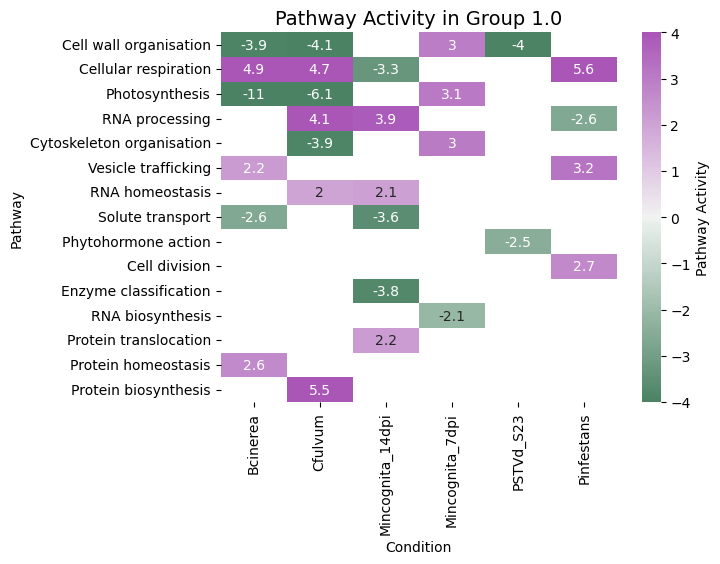

Processing MegaCluster 2.0


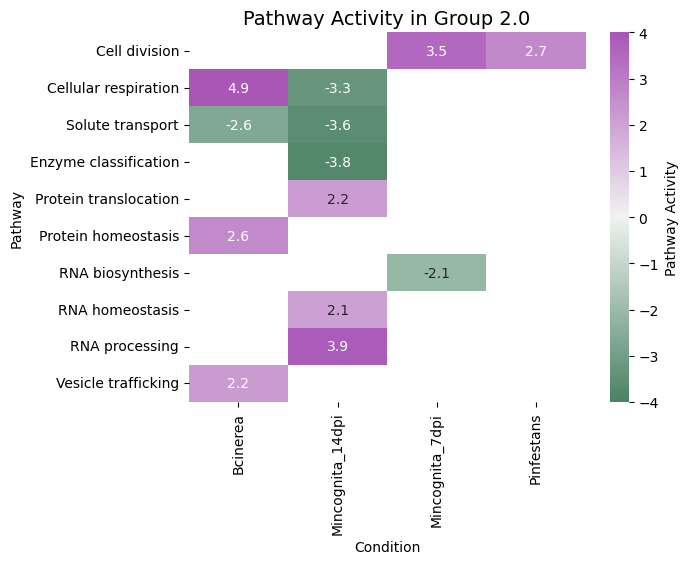

Processing MegaCluster 3.0


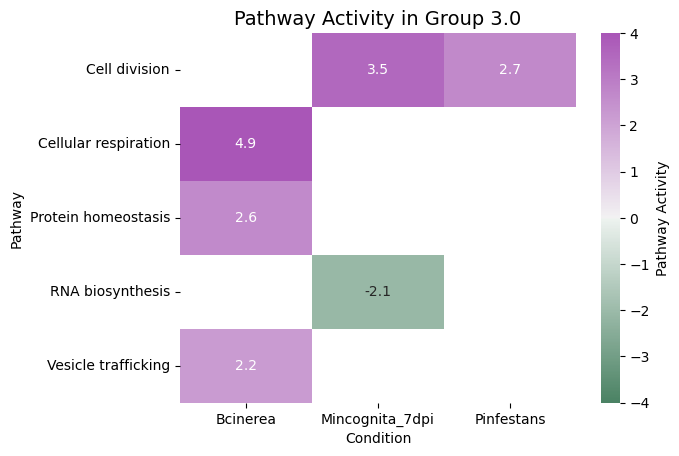

Processing MegaCluster 4.0


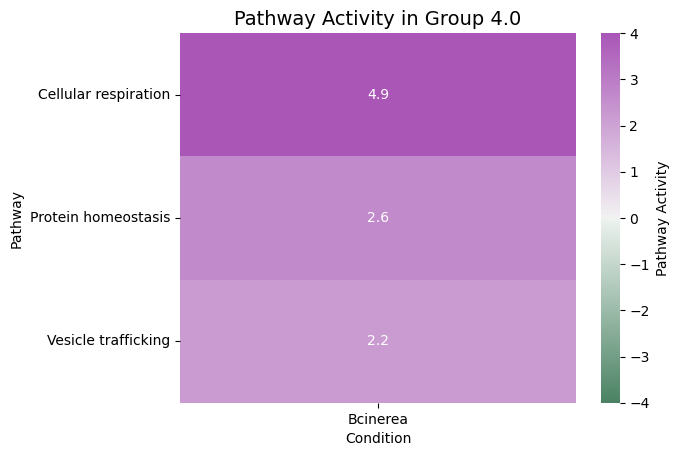

In [18]:
for megaclust in group_dict.keys():
    if megaclust != 0:
        print(f"Processing MegaCluster {megaclust}")
        TF_in_megaclust = group_dict[megaclust]
        triplet_sub = triplet[triplet['TF'].isin(TF_in_megaclust)]
        filtered_triplet_sub = triplet_sub[triplet_sub['TF_Activity'] != 0]
        pathway_acts_sub_group = filtered_triplet_sub.pivot_table(index='Pathway', columns='Condition', values='Pathway_Activity')
        pathway_acts_sub_group = pathway_acts_sub_group.fillna(0)
        pathway_acts_sub_group = pathway_acts_sub_group.loc[(pathway_acts_sub_group != 0).any(axis=1),(pathway_acts_sub_group != 0).any(axis=0)]
        n_cond = (pathway_acts_sub_group != 0).sum(axis=1)
        pathway_acts_sub_group = pathway_acts_sub_group.loc[n_cond.sort_values(ascending=False).index]
        mask = (pathway_acts_sub_group == 0)
        # pathway_acts_sub_group = pathway_acts_sub_group.replace(0, np.nan)
        # fig = sankey_pathway_activity(pathway_acts_sub_group, title=f"Pathway activity Sankey in group {megaclust}")
        # fig.write_image(f'Plot/Sankey_pathway_group_{megaclust}_corrected.svg', format='svg')
        if pathway_acts_sub_group.shape[1] > 1 :
            fig = sns.heatmap(pathway_acts_sub_group, mask=mask,
                cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True), 
                center=0, 
                cbar_kws={'label': 'Pathway Activity'}, 
                vmin = -4, 
                vmax = 4, annot=True) 
            plt.title(f"Pathway Activity in Group {megaclust}", fontsize=14)
            plt.savefig(f'Plot/Heatmap_pathway_group_{megaclust}_corrected.svg', format='svg')
            plt.show()
        else:
            fig = sns.heatmap(pathway_acts_sub_group, mask=mask,
               cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True), 
               center=0, 
               cbar_kws={'label': 'Pathway Activity'}, 
               vmin = -4, 
               vmax = 4, annot=True) 
            plt.title(f"Pathway Activity in Group {megaclust}", fontsize=14)
            plt.savefig(f'Plot/Heatmap_pathway_group_{megaclust}_corrected.svg', format='svg')
            plt.show()
        # fig.show()
        

In [19]:
# for megaclust in group_dict.keys():
#     if megaclust != 0:
#         print(f"Processing MegaCluster {megaclust}")

#         TF_in_megaclust = group_dict[megaclust]
#         triplet_sub = triplet[triplet['TF'].isin(TF_in_megaclust)]
#         filtered_triplet_sub = triplet_sub[triplet_sub['TF_Activity'] != 0]

#         pathway_acts_sub_group = filtered_triplet_sub.pivot_table(
#             index='Pathway',
#             columns='Condition',
#             values='Pathway_Activity'
#         ).fillna(0)

#         pathway_acts_sub_group = pathway_acts_sub_group.loc[
#             (pathway_acts_sub_group != 0).any(axis=1),
#             (pathway_acts_sub_group != 0).any(axis=0)
#         ]

#         # ===== UpSet conversion =====
#         # Presence / absence information (same as heatmap mask)
#         presence_df = pathway_acts_sub_group != 0

#         # Convert to UpSet format
#         upset_data = from_indicators(presence_df.columns, presence_df)

#         if presence_df.shape[1] > 1:
#             plt.figure(figsize=(8, 5))

#             upset = UpSet(
#                 upset_data,
#                 subset_size='count',
#                 sort_by='-degree'
#             )

#             upset.plot()
#             plt.suptitle(f"Pathway Activity Overlap in Group {megaclust}", fontsize=14)

#             plt.savefig(
#                 f'Plot/UpSet_pathway_group_{megaclust}_corrected.svg',
#                 format='svg'
#             )
#             plt.show()

#         else:
#             print(f"Only one condition in MegaCluster {megaclust} – UpSet not meaningful")


In [20]:

# for megaclust in group_dict.keys():
#     if megaclust != 0:
#         print(f"Processing MegaCluster {megaclust}")

#         TF_in_megaclust = group_dict[megaclust]
#         triplet_sub = triplet[triplet['TF'].isin(TF_in_megaclust)]
#         filtered_triplet_sub = triplet_sub[triplet_sub['TF_Activity'] != 0]

#         pathway_acts_sub_group = filtered_triplet_sub.pivot_table(
#             index='Pathway',
#             columns='Condition',
#             values='Pathway_Activity'
#         ).fillna(0)

#         pathway_acts_sub_group = pathway_acts_sub_group.loc[
#             (pathway_acts_sub_group != 0).any(axis=1),
#             (pathway_acts_sub_group != 0).any(axis=0)
#         ]

#         # ==========================================================
#         # Split by sign
#         # ==========================================================
#         sign_sets = {
#             "Activated": pathway_acts_sub_group > 0,
#             "Repressed": pathway_acts_sub_group < 0
#         }

#         for label, presence_df in sign_sets.items():

#             # Remove empty rows/columns
#             presence_df = presence_df.loc[
#                 presence_df.any(axis=1),
#                 presence_df.any(axis=0)
#             ]

#             if presence_df.shape[1] <= 1:
#                 print(
#                     f"{label}: only one condition in MegaCluster {megaclust} – UpSet skipped"
#                 )
#                 continue

#             # Convert to UpSet format
#             upset_data = from_indicators(presence_df.columns, presence_df)

#             plt.figure(figsize=(8, 5))

#             upset = UpSet(
#                 upset_data,
#                 subset_size='count',
#                 sort_by='-degree',
#                 show_counts=True
#             )

#             upset.plot()
#             plt.suptitle(
#                 f"{label} Pathway Overlap in Group {megaclust}",
#                 fontsize=14
#             )

#             plt.savefig(
#                 f"Plot/UpSet_{label.lower()}_pathway_group_{megaclust}_corrected.svg",
#                 format='svg'
#             )
#             plt.show()


TF - Pathway link in the hub GRN

In [21]:
# grn_hubs = pd.read_csv("./Network_GRN_hubs.txt", sep="\t")
# grn_hubs.rename(columns={"TF": "source", "Target_Gene": "target"}, inplace=True)

In [22]:
# triplet = fc.compute_tf_pathway_association(tf_activity=tf_acts, pathway_activity=pathway_acts_signif, tf_target_net=grn_hubs, pathway_target_net=network_pathway_mercator, method='sign')

In [23]:
# cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)
# for cond in conditions:
#     fig = fc.plot_tf_pathway_network(triplet, cond, cmap=cmap, association_mode='sign')
#     if fig is not None:
#         fig.savefig(f'Plot/Network_hubs_TF_pathway_{cond}.svg', format='svg')